In [8]:
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# --- Stałe pojazdu ---
MASS = 700              # Masa pojazdu (kg)
H = 0.511               # Wysokość środka ciężkości (m)
XC = -0.04              # Przesunięcie środka ciężkości wzdłuż osi (m)
WHEELBASE = 2.75        # Rozstaw osi (m)
TRACK_WIDTH = 1.7       # Rozstaw kół (m)
MU = 0.8                # Współczynnik tarcia opony
WHEEL_DIAMETER = 0.7    # Średnica koła (m)
G = 9.81                # Przyspieszenie grawitacyjne (m/s^2)
WHEEL_RADIUS = WHEEL_DIAMETER / 2  # Promień koła (m)

In [10]:
def calculate_torque_vectoring(turn_radius, velocity):
    """
    Oblicza momenty napędowe na wewnętrzne i zewnętrzne koło tylnej osi w zakręcie,
    uwzględniając rozkład sił przód-tył oraz siły odśrodkowe, z dodanym warunkiem poślizgu całego pojazdu.

    :param turn_radius: Promień zakrętu (m)
    :param velocity: Prędkość pojazdu (m/s)
    :return: Moment na koło wewnętrzne (Nm), moment na koło zewnętrzne (Nm), Czy pojazd w poślizgu (True/False)
    """
    
    # Siła odśrodkowa
    f_centrifugal = (MASS * velocity ** 2) / turn_radius
    
    # Maksymalna siła tarcia całego pojazdu
    max_total_grip = MU * (MASS * G)
    
    # Sprawdzenie, czy pojazd wpada w poślizg
    if f_centrifugal > max_total_grip:
        return 0, 0, False  # Pojazd w poślizgu, momenty ustawione na 0
    
    # Rozkład obciążenia przód-tył
    f_front = (MASS * G / 2) - (MASS * G * XC / WHEELBASE)
    f_rear = (MASS * G / 2) + (MASS * G * XC / WHEELBASE)
    
    # Maksymalna siła przyczepności osi tylnej
    f_rear_grip = f_rear * MU
    
    # Rozkład sił na lewe i prawe koła tylne
    f_left_rear = (f_rear / 2) + (f_centrifugal * H / TRACK_WIDTH)
    f_right_rear = (f_rear / 2) - (f_centrifugal * H / TRACK_WIDTH)
    
    # Maksymalne siły przyczepności dla kół
    f_max_left_rear = f_left_rear * MU
    f_max_right_rear = f_right_rear * MU
    
    # Maksymalne momenty na koła tylne
    m_left_rear = f_max_left_rear * WHEEL_RADIUS
    m_right_rear = f_max_right_rear * WHEEL_RADIUS
    
    return m_right_rear, m_left_rear, True  # Zwracamy momenty i brak poślizgu


In [19]:
turn_radius = [10, 15, 20, 25, 30]  # Promień zakrętu od 10 do 30 metrów
velocity = np.linspace(1, 10, 100)  # Prędkość od 1 do 10 m/s (100 punktów)

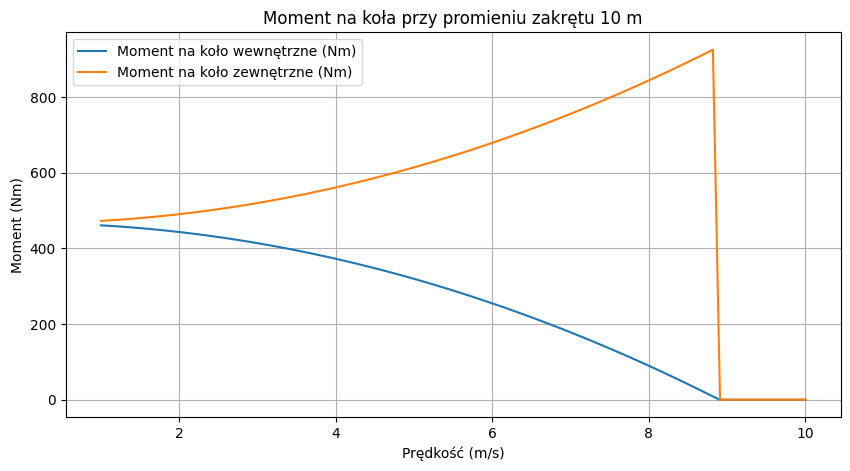

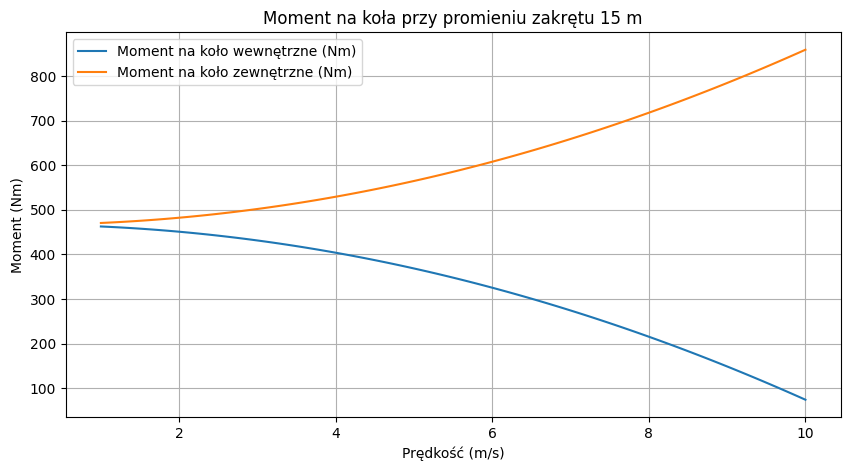

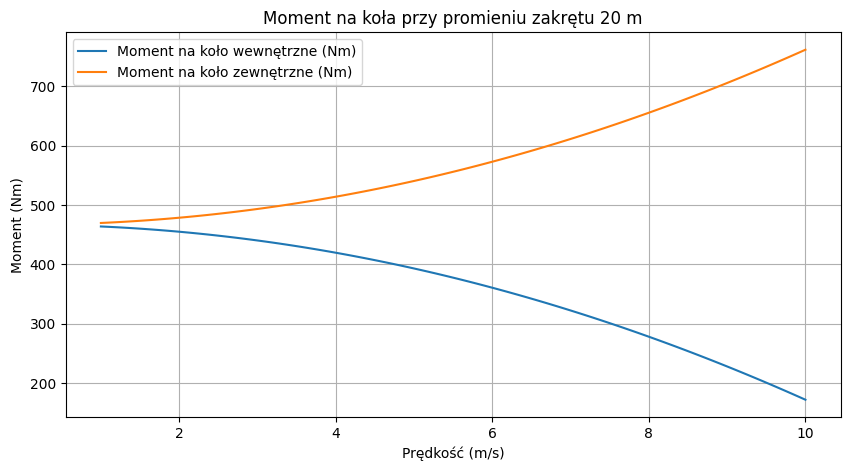

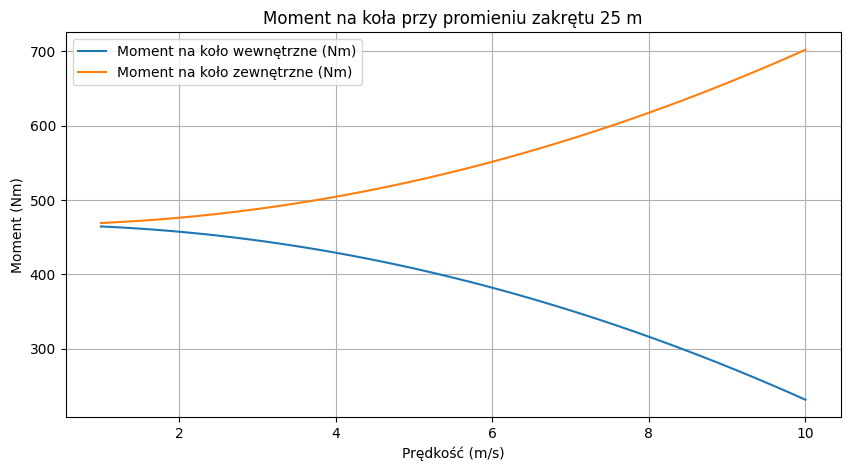

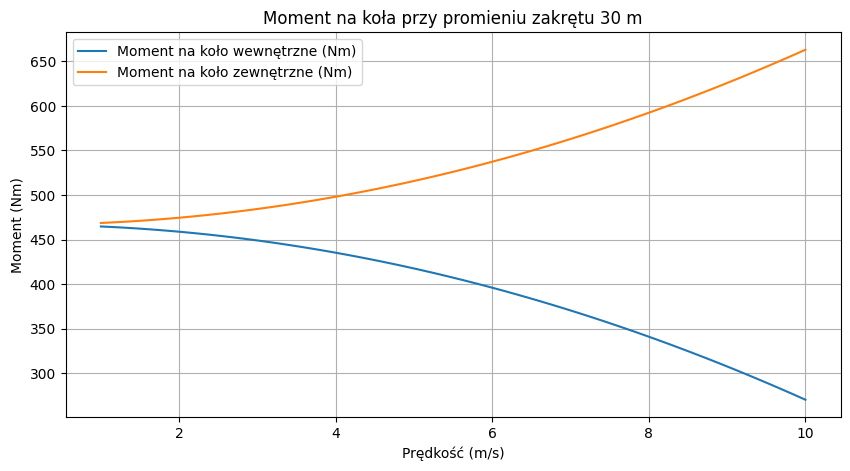

In [20]:

for r in turn_radius:
    plot_data = []
    for v in velocity:
        m_left, m_right, slip = calculate_torque_vectoring(r, v)
        plot_data.append((m_left, m_right, slip))
    #rysowanie wykresu
    plt.figure(figsize=(10, 5))
    plt.plot(velocity, [data[0] for data in plot_data], label='Moment na koło wewnętrzne (Nm)')
    plt.plot(velocity, [data[1] for data in plot_data], label='Moment na koło zewnętrzne (Nm)')
    plt.title(f'Moment na koła przy promieniu zakrętu {r} m')
    plt.xlabel('Prędkość (m/s)')
    plt.ylabel('Moment (Nm)')
    plt.legend()
    plt.grid()